In [5]:
import cv2
import cv2.face
import numpy as np
import os
import glob
import zipfile
import random
import time
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import Counter

print(f"OpenCV version : {cv2.__version__}")
print(f"NumPy  version : {np.__version__}")
print()
print(f"LBPH available      : {hasattr(cv2.face, 'LBPHFaceRecognizer_create')}")
print(f"EigenFace available : {hasattr(cv2.face, 'EigenFaceRecognizer_create')}")
print(f"FisherFace available: {hasattr(cv2.face, 'FisherFaceRecognizer_create')}")

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# ── Configuration ─────────────────────────────────────────────────────────────
ZIP_PATH = r"C:\FacialMoodDetection\FMDuOPCV.zip"
INNER_PATH = "CK+48"                                    # path inside the zip

IMG_SIZE   = (100, 100)
TEST_SPLIT = 0.20

MODEL_LBPH   = "./model_lbph.yml"
MODEL_EIGEN  = "./model_eigen.yml"
MODEL_FISHER = "./model_fisher.yml"

EMOTIONS  = ["anger", "contempt", "disgust", "fear", "happy", "sadness", "surprise"]
LABEL_MAP = {e: i for i, e in enumerate(EMOTIONS)}
print("\nLabel map:", LABEL_MAP)

OpenCV version : 4.13.0
NumPy  version : 2.4.3

LBPH available      : True
EigenFace available : True
FisherFace available: True

Label map: {'anger': 0, 'contempt': 1, 'disgust': 2, 'fear': 3, 'happy': 4, 'sadness': 5, 'surprise': 6}


In [6]:
import zipfile

try:
    with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
        all_files = zf.namelist()
        print(f"✅ ZIP opened successfully — {len(all_files)} files found")
        print("\nFirst 10 entries:")
        for f in all_files[:10]:
            print(f"  {f}")
        print()
        print("Emotion folder check:")
        for emotion in EMOTIONS:
            prefix = f"{INNER_PATH}/{emotion}/"
            count  = sum(1 for f in all_files if f.startswith(prefix))
            status = "✅" if count > 0 else "❌"
            print(f"  {status} {emotion:<12} — {count} images")
except FileNotFoundError:
    print("❌ ZIP not found — check your ZIP_PATH")
except zipfile.BadZipFile:
    print("❌ File is not a valid ZIP")

✅ ZIP opened successfully — 1962 files found

First 10 entries:
  CK+48/anger/S010_004_00000017.png
  CK+48/anger/S010_004_00000018.png
  CK+48/anger/S010_004_00000019.png
  CK+48/anger/S011_004_00000019.png
  CK+48/anger/S011_004_00000020.png
  CK+48/anger/S011_004_00000021.png
  CK+48/anger/S014_003_00000028.png
  CK+48/anger/S014_003_00000029.png
  CK+48/anger/S014_003_00000030.png
  CK+48/anger/S022_005_00000030.png

Emotion folder check:
  ✅ anger        — 135 images
  ✅ contempt     — 54 images
  ✅ disgust      — 177 images
  ✅ fear         — 75 images
  ✅ happy        — 207 images
  ✅ sadness      — 84 images
  ✅ surprise     — 249 images


In [7]:
face_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
)
assert not face_cascade.empty(), "ERROR: Haar Cascade failed to load!"
print("Haar Cascade loaded successfully.")


def detect_and_crop_face(gray_img):
    faces = face_cascade.detectMultiScale(
        gray_img,
        scaleFactor=1.1,
        minNeighbors=4,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE
    )
    if len(faces) == 0:
        return None
    x, y, w, h = max(faces, key=lambda r: r[2] * r[3])
    return gray_img[y:y + h, x:x + w]


def preprocess_image(img):
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face = detect_and_crop_face(gray)
    if face is None:
        face = gray
    face = cv2.resize(face, IMG_SIZE)
    face = cv2.equalizeHist(face)
    return face

print("Preprocessing functions ready.")

Haar Cascade loaded successfully.
Preprocessing functions ready.


In [8]:
def load_ckplus_from_zip(zip_path, inner_path, emotions):
    faces, labels = [], []
    skipped = 0

    with zipfile.ZipFile(zip_path, 'r') as zf:
        all_files = zf.namelist()

        print(f"{'Emotion':<12} {'Found':>6} {'Loaded':>7}")
        print("-" * 28)

        for emotion in emotions:
            prefix = f"{inner_path}/{emotion}/"
            img_files = [
                f for f in all_files
                if f.startswith(prefix)
                and f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ]
            loaded = 0
            for img_path in img_files:
                with zf.open(img_path) as f:
                    file_bytes = np.frombuffer(f.read(), dtype=np.uint8)
                    img = cv2.imdecode(file_bytes, cv2.IMREAD_COLOR)
                face = preprocess_image(img)
                if face is not None:
                    faces.append(face)
                    labels.append(LABEL_MAP[emotion])
                    loaded += 1
                else:
                    skipped += 1
            print(f"{emotion:<12} {len(img_files):>6} {loaded:>7}")

        print("-" * 28)
        print(f"{'TOTAL':<12} {'':>6} {len(faces):>7}")
        print(f"Skipped: {skipped}")

    return faces, labels


print("Loading CK+ dataset from ZIP...\n")
t0 = time.time()
faces, labels = load_ckplus_from_zip(ZIP_PATH, INNER_PATH, EMOTIONS)
print(f"\nTime: {time.time() - t0:.2f}s")

Loading CK+ dataset from ZIP...

Emotion       Found  Loaded
----------------------------
anger           135     135
contempt         54      54
disgust         177     177
fear             75      75
happy           207     207
sadness          84      84
surprise        249     249
----------------------------
TOTAL                   981
Skipped: 0

Time: 3.58s


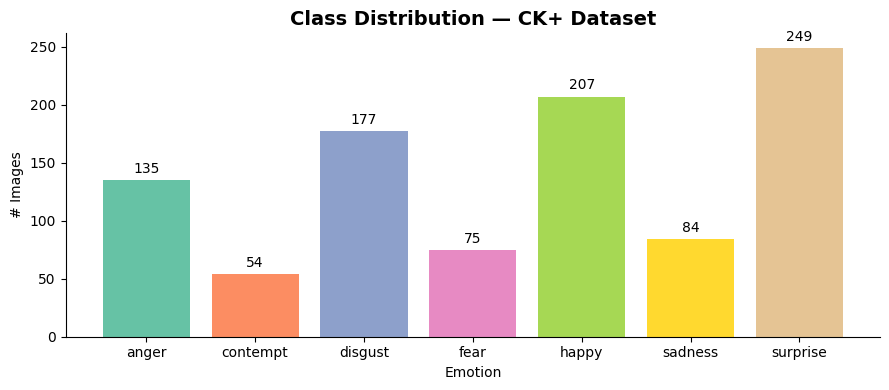

Saved: class_distribution.png


In [9]:
counts = Counter(labels)
fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.bar([EMOTIONS[l] for l in sorted(counts)],
              [counts[l]   for l in sorted(counts)],
              color=plt.cm.Set2.colors[:len(EMOTIONS)])
ax.bar_label(bars, padding=3)
ax.set_title("Class Distribution — CK+ Dataset", fontsize=14, fontweight="bold")
ax.set_xlabel("Emotion"); ax.set_ylabel("# Images")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("Saved: class_distribution.png")

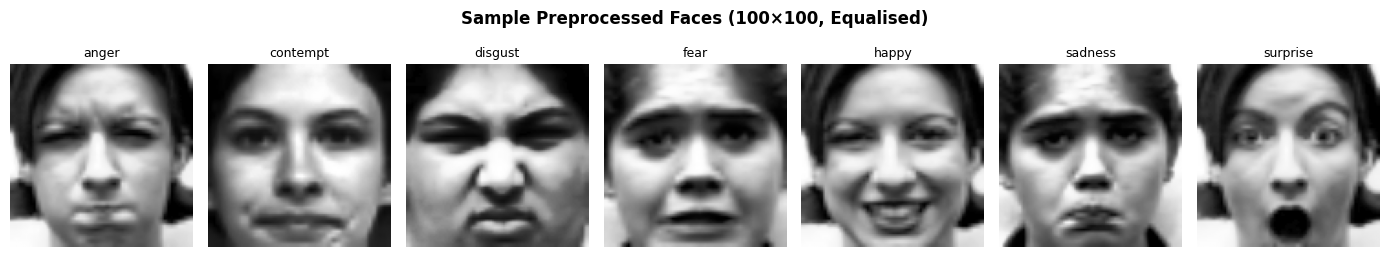

Saved: sample_faces.png


In [10]:
fig, axes = plt.subplots(1, len(EMOTIONS), figsize=(14, 2.5))
for ax, emotion in zip(axes, EMOTIONS):
    idx = next((i for i, l in enumerate(labels) if l == LABEL_MAP[emotion]), None)
    if idx is not None:
        ax.imshow(faces[idx], cmap="gray")
    ax.set_title(emotion, fontsize=9)
    ax.axis("off")
fig.suptitle("Sample Preprocessed Faces (100×100, Equalised)",
             fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("sample_faces.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sample_faces.png")

In [11]:
def stratified_split(faces, labels, test_ratio=0.2, seed=42):
    rng = np.random.RandomState(seed)
    arr = np.array(labels)
    train_idx, test_idx = [], []
    for cls in np.unique(arr):
        idx = rng.permutation(np.where(arr == cls)[0])
        n_test = max(1, int(len(idx) * test_ratio))
        test_idx.extend(idx[:n_test].tolist())
        train_idx.extend(idx[n_test:].tolist())
    fa = np.array(faces, dtype=object)
    return ([fa[i] for i in train_idx], [labels[i] for i in train_idx],
            [fa[i] for i in test_idx],  [labels[i] for i in test_idx])


train_faces, train_labels, test_faces, test_labels = stratified_split(
    faces, labels, test_ratio=TEST_SPLIT, seed=SEED
)
train_labels_np = np.array(train_labels, dtype=np.int32)
test_labels_np  = np.array(test_labels,  dtype=np.int32)

print(f"Training samples : {len(train_faces)}")
print(f"Test samples     : {len(test_faces)}")
print(f"Image shape      : {train_faces[0].shape}")

Training samples : 788
Test samples     : 193
Image shape      : (100, 100)


In [13]:
def train_recognizer(recognizer, faces, labels, name):
    print(f"  Training {name}...", end="", flush=True)
    t0 = time.time()
    # Convert to proper list of uint8 numpy arrays (required by cv2.face)
    faces_list = [np.array(f, dtype=np.uint8) for f in faces]
    recognizer.train(faces_list, labels)
    print(f" done in {time.time() - t0:.2f}s")
    return recognizer


print("Training OpenCV face recognizers:\n")

lbph = train_recognizer(
    cv2.face.LBPHFaceRecognizer_create(radius=1, neighbors=8, grid_x=8, grid_y=8),
    train_faces, train_labels_np, "LBPH"
)

eigen = train_recognizer(
    cv2.face.EigenFaceRecognizer_create(num_components=100),
    train_faces, train_labels_np, "EigenFace"
)

fisher = train_recognizer(
    cv2.face.FisherFaceRecognizer_create(num_components=0),
    train_faces, train_labels_np, "FisherFace"
)

print("\nAll recognizers trained successfully!")

Training OpenCV face recognizers:

  Training LBPH... done in 0.50s
  Training EigenFace... done in 11.58s
  Training FisherFace... done in 15.36s

All recognizers trained successfully!


In [14]:
def evaluate_recognizer(recognizer, test_faces, test_labels_np, name):
    faces_list = [np.array(f, dtype=np.uint8) for f in test_faces]
    y_pred = np.array([recognizer.predict(f)[0] for f in faces_list], dtype=np.int32)
    y_true = test_labels_np
    accuracy = np.mean(y_pred == y_true)
    n = len(EMOTIONS)

    cm = np.zeros((n, n), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    precs, recs, f1s = [], [], []
    for cls in range(n):
        tp = np.sum((y_pred == cls) & (y_true == cls))
        fp = np.sum((y_pred == cls) & (y_true != cls))
        fn = np.sum((y_pred != cls) & (y_true == cls))
        p  = tp / (tp + fp) if (tp + fp) else 0
        r  = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * p * r / (p + r) if (p + r) else 0
        precs.append(p); recs.append(r); f1s.append(f1)

    return dict(name=name, accuracy=accuracy, y_pred=y_pred, y_true=y_true,
                cm=cm, precisions=precs, recalls=recs, f1s=f1s)


print("Evaluating...\n")
results_lbph   = evaluate_recognizer(lbph,   test_faces, test_labels_np, "LBPH")
results_eigen  = evaluate_recognizer(eigen,  test_faces, test_labels_np, "EigenFace")
results_fisher = evaluate_recognizer(fisher, test_faces, test_labels_np, "FisherFace")
all_results = [results_lbph, results_eigen, results_fisher]

print(f"{'Recognizer':<14} {'Accuracy':>10} {'Macro P':>9} {'Macro R':>9} {'Macro F1':>10}")
print("=" * 56)
for r in all_results:
    print(f"{r['name']:<14} "
          f"{r['accuracy']*100:>9.2f}% "
          f"{np.mean(r['precisions'])*100:>8.2f}% "
          f"{np.mean(r['recalls'])*100:>8.2f}% "
          f"{np.mean(r['f1s'])*100:>9.2f}%")
print("=" * 56)

Evaluating...

Recognizer       Accuracy   Macro P   Macro R   Macro F1
LBPH               98.96%    99.09%    98.76%     98.90%
EigenFace          96.37%    95.26%    93.71%     94.33%
FisherFace         94.82%    93.93%    92.66%     93.21%


In [15]:
best = max(all_results, key=lambda r: r['accuracy'])
print(f"Best model: {best['name']} — {best['accuracy']*100:.2f}% accuracy\n")
print(f"{'Emotion':<12} {'Precision':>10} {'Recall':>8} {'F1':>8} {'Support':>9}")
print("-" * 52)
for cls in range(len(EMOTIONS)):
    sup = int(np.sum(best['y_true'] == cls))
    print(f"{EMOTIONS[cls]:<12} "
          f"{best['precisions'][cls]:>10.3f} "
          f"{best['recalls'][cls]:>8.3f} "
          f"{best['f1s'][cls]:>8.3f} "
          f"{sup:>9}")
print("-" * 52)
print(f"{'Macro avg':<12} "
      f"{np.mean(best['precisions']):>10.3f} "
      f"{np.mean(best['recalls']):>8.3f} "
      f"{np.mean(best['f1s']):>8.3f} "
      f"{len(best['y_true']):>9}")

Best model: LBPH — 98.96% accuracy

Emotion       Precision   Recall       F1   Support
----------------------------------------------------
anger             0.964    1.000    0.982        27
contempt          1.000    1.000    1.000        10
disgust           0.972    1.000    0.986        35
fear              1.000    1.000    1.000        15
happy             1.000    0.976    0.988        41
sadness           1.000    0.938    0.968        16
surprise          1.000    1.000    1.000        49
----------------------------------------------------
Macro avg         0.991    0.988    0.989       193


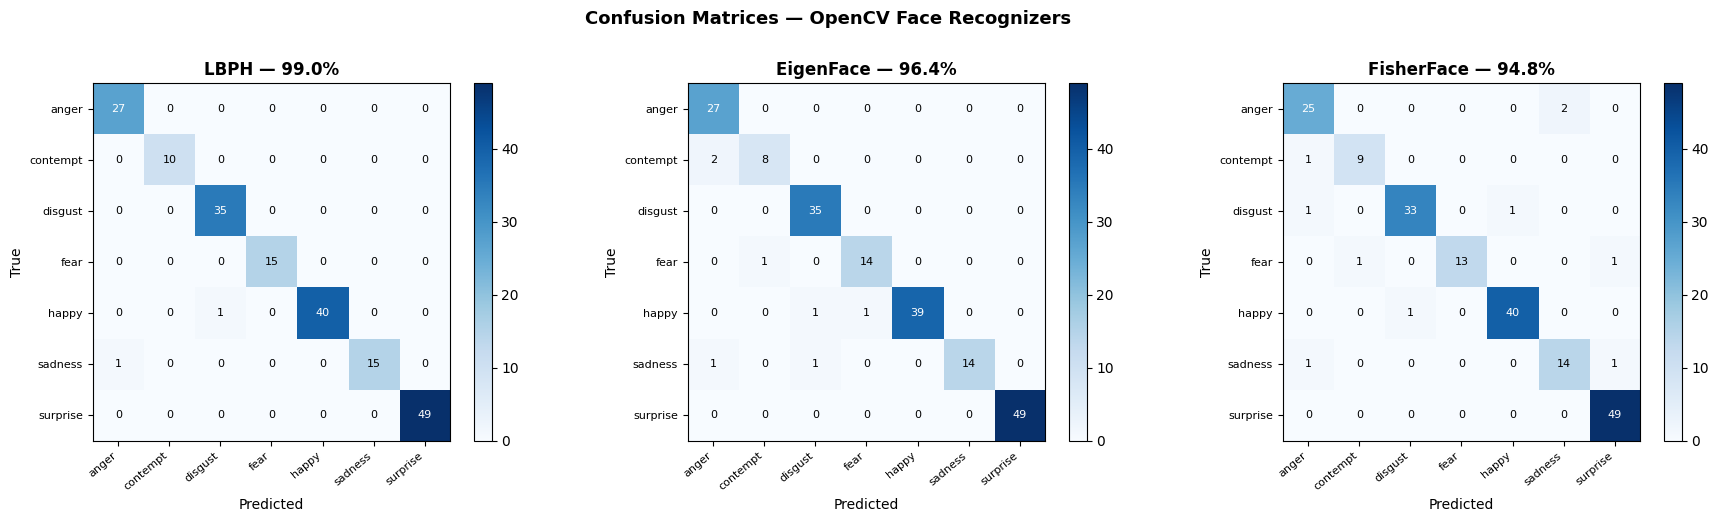

Saved: confusion_matrices.png


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, r in zip(axes, all_results):
    im = ax.imshow(r['cm'], interpolation="nearest", cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax, fraction=0.046)
    ticks = np.arange(len(EMOTIONS))
    ax.set_xticks(ticks); ax.set_xticklabels(EMOTIONS, rotation=40, ha="right", fontsize=8)
    ax.set_yticks(ticks); ax.set_yticklabels(EMOTIONS, fontsize=8)
    thresh = r['cm'].max() / 2.
    for i in range(len(EMOTIONS)):
        for j in range(len(EMOTIONS)):
            ax.text(j, i, str(r['cm'][i, j]), ha="center", va="center", fontsize=8,
                    color="white" if r['cm'][i, j] > thresh else "black")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(f"{r['name']} — {r['accuracy']*100:.1f}%", fontweight="bold")
plt.suptitle("Confusion Matrices — OpenCV Face Recognizers",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: confusion_matrices.png")

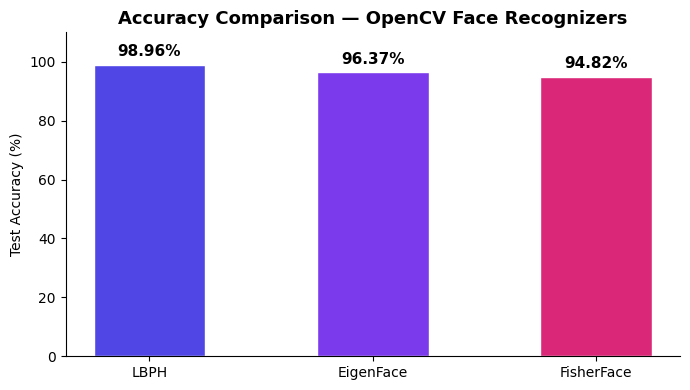

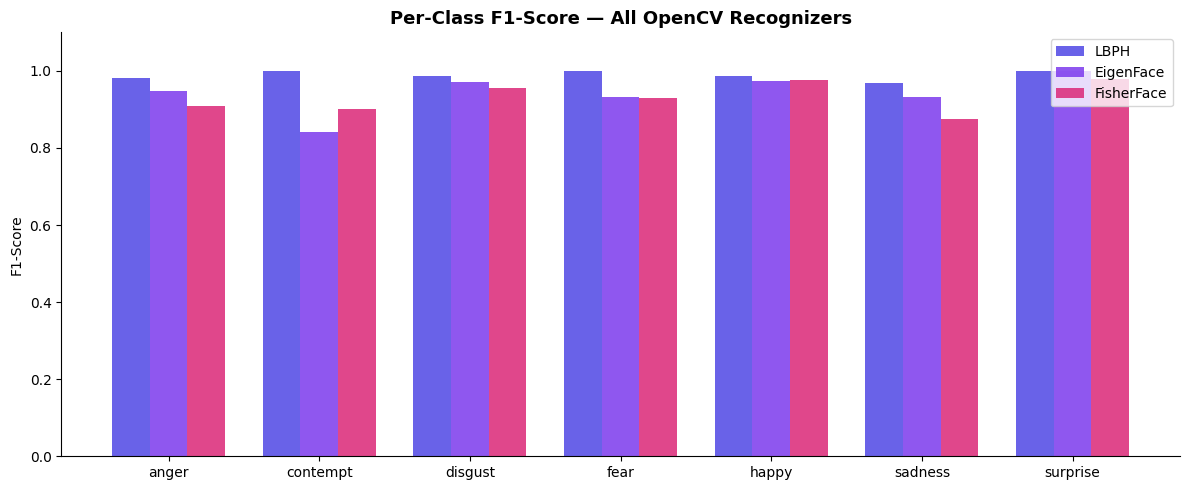

Saved: accuracy_comparison.png & per_class_f1.png


In [17]:
# Accuracy comparison bar chart
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar([r['name'] for r in all_results],
              [r['accuracy'] * 100 for r in all_results],
              color=["#4f46e5", "#7c3aed", "#db2777"], width=0.5, edgecolor="white")
ax.bar_label(bars, fmt="%.2f%%", padding=4, fontsize=11, fontweight="bold")
ax.set_ylim(0, 110)
ax.set_ylabel("Test Accuracy (%)")
ax.set_title("Accuracy Comparison — OpenCV Face Recognizers", fontsize=13, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("accuracy_comparison.png", dpi=150)
plt.show()

# Per-class F1 grouped bar chart
x = np.arange(len(EMOTIONS))
width = 0.25
fig, ax = plt.subplots(figsize=(12, 5))
for i, r in enumerate(all_results):
    ax.bar(x + i * width, r['f1s'], width, label=r['name'],
           color=["#4f46e5", "#7c3aed", "#db2777"][i], alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(EMOTIONS)
ax.set_ylim(0, 1.1)
ax.set_ylabel("F1-Score")
ax.set_title("Per-Class F1-Score — All OpenCV Recognizers", fontsize=13, fontweight="bold")
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.savefig("per_class_f1.png", dpi=150)
plt.show()
print("Saved: accuracy_comparison.png & per_class_f1.png")

In [18]:
lbph.save(MODEL_LBPH)
eigen.save(MODEL_EIGEN)
fisher.save(MODEL_FISHER)
print(f"Saved: {MODEL_LBPH}")
print(f"Saved: {MODEL_EIGEN}")
print(f"Saved: {MODEL_FISHER}")

# Verify LBPH reload
lbph_verify = cv2.face.LBPHFaceRecognizer_create()
lbph_verify.read(MODEL_LBPH)
faces_list = [np.array(f, dtype=np.uint8) for f in test_faces]
v_preds = np.array([lbph_verify.predict(f)[0] for f in faces_list], dtype=np.int32)
v_acc   = np.mean(v_preds == test_labels_np)
print(f"\nLBPH reload verification: {v_acc*100:.2f}% — {'OK ✅' if abs(v_acc - results_lbph['accuracy']) < 1e-9 else 'MISMATCH ❌'}")

Saved: ./model_lbph.yml
Saved: ./model_eigen.yml
Saved: ./model_fisher.yml

LBPH reload verification: 98.96% — OK ✅


In [19]:
def predict_mood(img_path, recognizer=lbph):
    """
    Predict emotion from an image file.
    Returns (emotion_str, confidence).
    For LBPH: lower confidence = better (it is a distance score).
    """
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot read: {img_path}")
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    face = detect_and_crop_face(gray)
    if face is None:
        face = gray
    face = cv2.resize(face, IMG_SIZE)
    face = cv2.equalizeHist(face)
    face = np.array(face, dtype=np.uint8)
    label, confidence = recognizer.predict(face)
    return EMOTIONS[label], confidence


def visualise_prediction(img_path, recognizer=lbph):
    """Predict and display image with bounding box and label."""
    img_bgr = cv2.imread(img_path)
    gray    = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    detected = face_cascade.detectMultiScale(gray, 1.1, 4, minSize=(30, 30))
    mood, conf = predict_mood(img_path, recognizer)

    display = img_bgr.copy()
    for (x, y, w, h) in detected:
        cv2.rectangle(display, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.putText(display, f"{mood} ({conf:.1f})",
                    (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.75, (0, 255, 0), 2)

    plt.figure(figsize=(5, 5))
    plt.imshow(cv2.cvtColor(display, cv2.COLOR_BGR2RGB))
    plt.title(f"Predicted: {mood}  |  Confidence: {conf:.1f}",
              fontsize=12, fontweight="bold")
    plt.axis("off")
    plt.tight_layout()
    plt.show()
    return mood, conf


print("✅ Project complete! All cells done.")
print()
print("To predict on a new image:")
print('  mood, conf = predict_mood(r"C:\\path\\to\\image.jpg")')
print('  mood, conf = visualise_prediction(r"C:\\path\\to\\image.jpg")')

✅ Project complete! All cells done.

To predict on a new image:
  mood, conf = predict_mood(r"C:\path\to\image.jpg")
  mood, conf = visualise_prediction(r"C:\path\to\image.jpg")


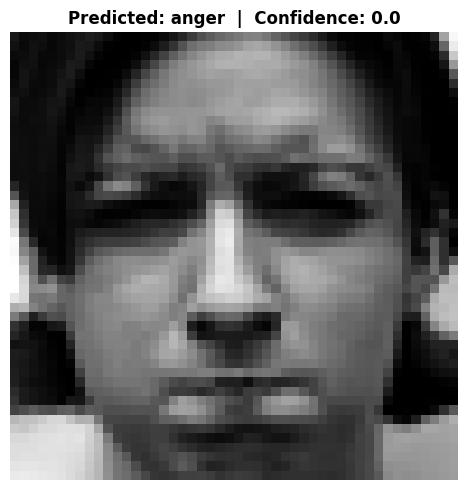

Predicted: anger, Confidence: 0.0


In [21]:
import zipfile
import tempfile

# Extract one test image temporarily to test prediction
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    # Get first anger image from zip
    test_img_path_in_zip = "CK+48/anger/S010_004_00000017.png"
    zf.extract(test_img_path_in_zip, "C:/FacialMoodDetection/temp/")

# Now predict on it
mood, conf = visualise_prediction(
    r"C:\FacialMoodDetection\temp\CK+48\anger\S010_004_00000017.png"
)
print(f"Predicted: {mood}, Confidence: {conf:.1f}")

In [26]:
def run_webcam_demo(recognizer=lbph, recognizer_name="LBPH", duration=60):
    """
    Opens webcam with real-time mood detection overlay.
    Press 'q' to quit early. Auto-stops after `duration` seconds.
    """
    cap = cv2.VideoCapture(0)
    if not cap.isOpened():
        print("ERROR: Cannot access webcam. Check your camera is connected.")
        return

    print(f"Live webcam demo ({recognizer_name}) started!")
    print("Press 'q' to quit early.")
    start = time.time()

    while True:
        ret, frame = cap.read()
        if not ret:
            print("ERROR: Cannot read from webcam.")
            break

        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        faces_det = face_cascade.detectMultiScale(
            gray,
            scaleFactor=1.1,
            minNeighbors=4,
            minSize=(30, 30)
        )

        for (x, y, w, h) in faces_det:
            # Preprocess the detected face ROI
            roi = gray[y:y + h, x:x + w]
            roi = cv2.resize(roi, IMG_SIZE)
            roi = cv2.equalizeHist(roi)
            roi = np.array(roi, dtype=np.uint8)

            # Predict mood
            label, confidence = recognizer.predict(roi)
            mood = EMOTIONS[label]

            # Draw bounding box
            cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 2)

            # Draw mood label above the box
            label_text = f"{mood} ({confidence:.1f})"
            cv2.putText(frame, label_text,
                        (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8, (0, 255, 0), 2)

            # Draw filled background behind text for readability
            text_size = cv2.getTextSize(label_text,
                                        cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)[0]
            cv2.rectangle(frame,
                          (x, y - 35),
                          (x + text_size[0], y - 10),
                          (0, 255, 0), -1)
            cv2.putText(frame, label_text,
                        (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.8, (0, 0, 0), 2)

        # Show elapsed time and recognizer name
        elapsed = int(time.time() - start)
        remaining = duration - elapsed
        info_text = f"{recognizer_name} | Time: {elapsed}s | Press Q to quit"
        cv2.putText(frame, info_text,
                    (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.65, (255, 255, 0), 2)

        # Show face count
        face_count = len(faces_det)
        cv2.putText(frame, f"Faces detected: {face_count}",
                    (10, 60),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.65, (255, 255, 0), 2)

        cv2.imshow(f"Facial Mood Detection — {recognizer_name}", frame)

        # Quit on 'q' or after duration
        if cv2.waitKey(1) & 0xFF == ord('q'):
            print("Quit by user.")
            break
        if time.time() - start > duration:
            print(f"Auto-stopped after {duration} seconds.")
            break

    cap.release()
    cv2.destroyAllWindows()
    print("Webcam demo ended.")


# ── Run the webcam demo ────────────────────────────────────────────────────────
# Choose your preferred recognizer:
run_webcam_demo(recognizer=lbph,   recognizer_name="LBPH",       duration=60)
# run_webcam_demo(recognizer=fisher, recognizer_name="FisherFace", duration=60)
# run_webcam_demo(recognizer=eigen,  recognizer_name="EigenFace",  duration=60)

Live webcam demo (LBPH) started!
Press 'q' to quit early.
Quit by user.
Webcam demo ended.
